# **LightGBM with AUC & ROC Curve**

### Import necessary libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 

### Import and read the dataset

In [3]:
df=pd.read_csv(r'D:\fsds\materials\class materials\august\2nd, 4th- ENSAMBLE LEARNING\Breast_cancer_data.csv')
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


### Summary of Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


### Checking the distribution of target variable 

In [5]:
df['diagnosis'].value_counts()

diagnosis
1    357
0    212
Name: count, dtype: int64

In [7]:
X = df[['mean_radius','mean_texture','mean_perimeter','mean_area','mean_smoothness']]
y=df['diagnosis']

### Splitting data into train and test data

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Building LightGBM Model 

In [9]:
import lightgbm as lgb
classifier = lgb.LGBMClassifier()
classifier.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 290, number of negative: 165
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 760
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.637363 -> initscore=0.563935
[LightGBM] [Info] Start training from score 0.563935
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMClassifier()

### Predicting the results

In [12]:
y_pred = classifier.predict(X_test)


In [14]:
from sklearn.metrics import accuracy_score

ac= accuracy_score(y_test, y_pred)
print('LightGBM Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

LightGBM Model accuracy score: 0.9298


### Comparing train and test set accuracy 

In [15]:
y_pred_train = classifier.predict(X_train)
print('LightGBM Model train accuracy score: {0:0.4f}'.format(accuracy_score(y_train, y_pred_train)))

LightGBM Model train accuracy score: 1.0000


### Checking for overfitting

In [16]:
print('LightGBM Model train accuracy score: {0:0.4f}'.format(accuracy_score(y_train, y_pred_train)))
print('LightGBM Model test accuracy score: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))

LightGBM Model train accuracy score: 1.0000
LightGBM Model test accuracy score: 0.9298


### Comments:
- we can see that the training set accuracy and test set accuracy are pretty close.
- from the above observation, we can come to a conclusion that the there is no overfitting

### Confusion Matrix

In [17]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test, y_pred)
print(f'Confusion Matrix:\n{cm}')

Confusion Matrix:
[[42  5]
 [ 3 64]]


### Visualizing confusion matrix using heatmap

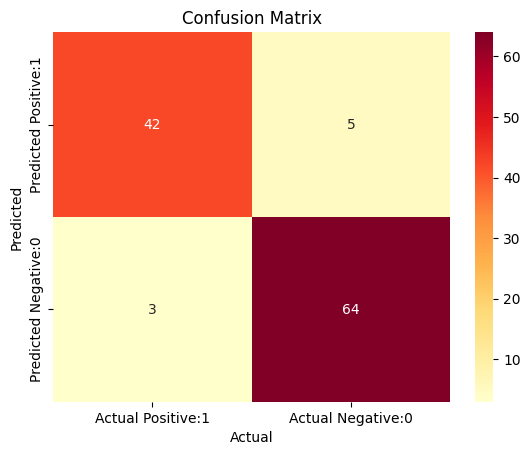

In [28]:
cm_matrix= pd.DataFrame(data=cm, columns=['Actual Positive:1','Actual Negative:0'], index=['Predicted Positive:1','Predicted Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlOrRd', )
plt.title('Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

### Classification Metrics

In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.89      0.91        47
           1       0.93      0.96      0.94        67

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.93       114
weighted avg       0.93      0.93      0.93       114



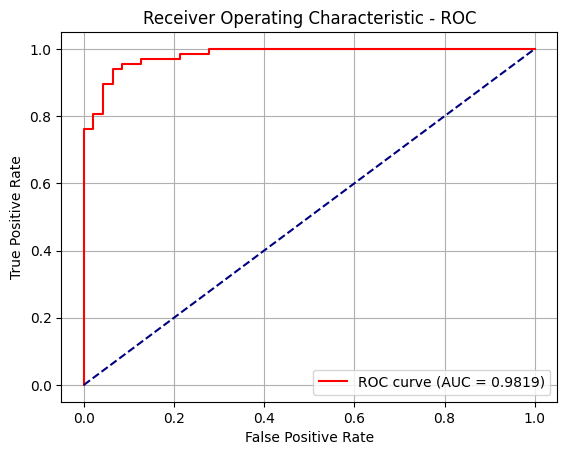

In [35]:
from sklearn.metrics import roc_auc_score, roc_curve

# Get predicted probabilities for the positive class
y_probs = classifier.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='red', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - ROC')
plt.legend(loc="lower right")
plt.grid()
plt.show()

